<a href="https://colab.research.google.com/github/MuhammadRibhiRamadan/fsi-prediction-id/blob/main/DSAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Predicting Food Security Index Using Food Price and Socioeconomic Indicators in Indonesia with Machine Learning Approach**

# **Import Library**

In [1]:
import pandas as pd              # for data manipulation and analysis
import numpy as np               # for numerical operations

import matplotlib.pyplot as plt  # for basic data visualization
import seaborn as sns            # for advanced statistical visualization

In [2]:
#connect Google Colab with Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Data Collection and Loading**

# Reading Dataset

***World Bank Food Price Dataset***

This dataset is obtained from the World Bank Real-Time Prices (RTP) system, developed by the World Bank Development Economics Data Group (DECDG). It provides monthly food price estimates derived from multiple sources, including the World Food Programme (WFP), the Food and Agriculture Organization (FAO), and national statistical offices. Machine learning techniques are applied to estimate missing values and ensure data completeness.

In [3]:
# collect World Bank Food Price data
food_raw_df = pd.read_csv('/content/drive/MyDrive/ProjectDSAI/IDN_RTFP_mkt_2007_2026-04-08.csv')

food_raw_df.head()

,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_sugar,c_sugar,inflation_sugar,trust_sugar,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-01-01,2007,...,9855.73,10080.27,NaN,8.8,0.62,0.63,0.62,0.62,NaN,9.2
1,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-02-01,2007,...,9888.89,10105.85,NaN,8.8,0.63,0.64,0.62,0.62,NaN,9.2
2,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-03-01,2007,...,9987.67,10237.43,NaN,8.8,0.62,0.63,0.61,0.63,NaN,9.2
3,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-04-01,2007,...,10101.85,10152.65,NaN,8.8,0.63,0.64,0.62,0.64,NaN,9.2
4,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-05-01,2007,...,9910.64,9910.64,NaN,8.8,0.64,0.65,0.63,0.63,NaN,9.2


In [4]:
# define year range
year_range = list(range(2020, 2026)) # 2020–2025

***Food Security and Vulnerability Atlas (FSVA)***

This dataset is obtained from the National Food Agency (Badan Pangan Nasional). It represents the Food Security Index (FSI) constructed from multiple indicators related to food availability, access, and utilization.

In [5]:
# collect FSVA data
fsva_list = []

for year in year_range:
    fsva_file = f'/content/drive/MyDrive/ProjectDSAI/tabel_data ({year}).csv'
    fsva_file_df = pd.read_csv(fsva_file)
    fsva_file_df['year'] = year
    fsva_list.append(fsva_file_df)

# concatenate FSVA dataset
fsva_raw_df = pd.concat(fsva_list, ignore_index=True)

fsva_raw_df.head()

,Wilayah,Komposit,NCPR,Kemiskinan (%),Pengeluaran Pangan (%),Tanpa Listrik (%),Tanpa Air Bersih (%),Lama Sekolah Perempuan (tahun),Rasio Tenaga Kesehatan,Angka Harapan Hidup (tahun),Stunting (%),IKP,IKP Ranking,Unnamed: 13,year
0,aceh - aceh selatan,5,0.80,13.09,54.14,0.77,42.92,9.01,5.08,64.27,0.00,71.92,271.0,NaN,2020
1,aceh - aceh tenggara,5,0.26,13.43,58.42,0.40,49.34,8.71,6.14,68.04,42.83,73.95,242.0,NaN,2020
2,aceh - aceh timur,5,0.55,14.47,58.23,0.87,44.30,8.16,3.09,68.67,25.50,74.10,238.0,NaN,2020
3,aceh - aceh tengah,5,1.54,15.50,27.05,0.08,36.60,9.79,3.35,68.82,42.87,71.07,276.0,NaN,2020
4,aceh - aceh barat,6,0.71,18.79,20.21,0.48,20.25,8.92,2.73,67.93,0.00,78.61,165.0,NaN,2020


***Socioeconomic Data from BPS***

This dataset includes poverty and population statistics obtained from Badan Pusat Statistik (BPS). The variables include poverty rate, poverty line, and total population at the provincial level.

In [6]:
# collect BPS data
bps_poverty_list = []
bps_population_list = []

for year in year_range:
    # poverty data
    poverty_file_df = f'/content/drive/MyDrive/ProjectDSAI/Jumlah dan Persentase Penduduk Miskin Menurut Provinsi, {year}.csv'
    poverty_bps_df = pd.read_csv(poverty_file_df)
    poverty_bps_df['year'] = year
    bps_poverty_list.append(poverty_bps_df)

    # population data
    population_file_df = f'/content/drive/MyDrive/ProjectDSAI/pop_{year}.csv'
    population_bps_df = pd.read_csv(population_file_df)
    population_bps_df['year'] = year
    bps_population_list.append(population_bps_df)

# concatenate BPS dataset
bps_poverty_raw_df = pd.concat(bps_poverty_list, ignore_index=True)
bps_population_raw_df = pd.concat(bps_population_list, ignore_index=True)

bps_poverty_raw_df.head()

,Provinsi,Garis Kemiskinan - Maret (Rp),Garis Kemiskinan - September (Rp),Jumlah Penduduk Miskin - Maret (ribu) (Ribu),Jumlah Penduduk Miskin - September (ribu) (Ribu),Persentase Penduduk Miskin - Maret,Persentase Penduduk Miskin - September,year
0,Aceh,522126,...,814.91,...,14.99,...,2020
1,Sumatera Utara,502904,...,1283.29,...,8.75,...,2020
2,Sumatera Barat,544315,...,344.23,...,6.28,...,2020
3,Riau,544057,...,483.39,...,6.82,...,2020
4,Jambi,483542,...,277.8,...,7.58,...,2020


# **Initial Data Analysis (IDA)**

In [7]:
# check the shape (number of rows and columns) of each dataset
print(food_raw_df.shape)
print(fsva_raw_df.shape)
print(bps_poverty_raw_df.shape)
print(bps_population_raw_df.shape)

# check missing values in each dataset
print(food_raw_df.isna().sum())
print(fsva_raw_df.isna().sum())
print(bps_poverty_raw_df.isna().sum())
print(bps_population_raw_df.isna().sum())

(51736, 95)
(3084, 15)
(232, 8)
(255, 7)
ISO3                             0
country                          0
adm1_name                        0
adm2_name                        0
mkt_name                         0
                              ... 
h_food_price_index               0
l_food_price_index               0
c_food_price_index               0
inflation_food_price_index    2676
trust_food_price_index           0
Length: 95, dtype: int64
Wilayah                              0
Komposit                             0
NCPR                               514
Kemiskinan (%)                     514
Pengeluaran Pangan (%)             514
Tanpa Listrik (%)                  514
Tanpa Air Bersih (%)               514
Lama Sekolah Perempuan (tahun)     514
Rasio Tenaga Kesehatan             514
Angka Harapan Hidup (tahun)        514
Stunting (%)                       514
IKP                                  0
IKP Ranking                        514
Unnamed: 13                       3084
yea

# **Dataset Cleaning**

Food Prices (WB)

In [8]:
food_raw_df.head()
food_raw_df.columns

Index(['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon',
       'geo_id', 'price_date', 'year', 'month', 'currency', 'components',
       'start_dense_data', 'last_survey_point', 'data_coverage',
       'data_coverage_recent', 'index_confidence_score',
       'spatially_interpolated', 'chili', 'eggs', 'garlic', 'meat_beef',
       'meat_chicken', 'meat_chicken_broiler', 'oil', 'onions', 'rice',
       'sugar', 'o_chili', 'h_chili', 'l_chili', 'c_chili', 'inflation_chili',
       'trust_chili', 'o_eggs', 'h_eggs', 'l_eggs', 'c_eggs', 'inflation_eggs',
       'trust_eggs', 'o_garlic', 'h_garlic', 'l_garlic', 'c_garlic',
       'inflation_garlic', 'trust_garlic', 'o_meat_beef', 'h_meat_beef',
       'l_meat_beef', 'c_meat_beef', 'inflation_meat_beef', 'trust_meat_beef',
       'o_meat_chicken', 'h_meat_chicken', 'l_meat_chicken', 'c_meat_chicken',
       'inflation_meat_chicken', 'trust_meat_chicken',
       'o_meat_chicken_broiler', 'h_meat_chicken_broiler',
       '

In [9]:
# filter data
food_raw_df = food_raw_df[food_raw_df['adm1_name'] != 'Market Average']
food_raw_df = food_raw_df[food_raw_df['year'].between(2020, 2025)]

In [10]:
# rename columns
food_raw_df = food_raw_df.rename(columns={
    'adm1_name': 'province',
    'c_chili': 'chili_price',
    'c_eggs': 'eggs_price',
    'c_garlic': 'garlic_price',
    'c_meat_beef': 'beef_price',
    'c_meat_chicken': 'chicken_price',
    'c_meat_chicken_broiler': 'chicken_broiler_price',
    'c_oil': 'oil_price',
    'c_onions': 'onions_price',
    'c_rice': 'rice_price',
    'c_sugar': 'sugar_price'
})

In [11]:
# select price columns
food_price_col = [col for col in food_raw_df.columns if col.endswith('_price')]

In [12]:
# aggregate annual data per province
food_clean = (
    food_raw_df
    .groupby(['province', 'year'])[food_price_col]
    .median()
    .reset_index()
)

In [13]:
# normalize province names
food_clean['province'] = food_clean['province'].str.upper().str.strip()

In [14]:
# check cleaned food dataset
print(food_clean.shape)
print(food_clean.columns.tolist())
food_clean.head()

(204, 12)
['province', 'year', 'chili_price', 'eggs_price', 'garlic_price', 'beef_price', 'chicken_price', 'chicken_broiler_price', 'oil_price', 'onions_price', 'rice_price', 'sugar_price']


,province,year,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price
0,ACEH,2020,32454.775,24277.195,27873.405,133545.040,28688.150,27966.310,13926.885,37454.915,10071.950,14370.070
1,ACEH,2021,37695.300,24856.380,26878.910,143272.525,29233.695,28676.815,15393.135,33084.295,9900.000,13500.000
2,ACEH,2022,48638.840,27860.225,26586.135,147054.050,29948.165,30000.000,20319.235,35890.205,10323.065,14730.835
3,ACEH,2023,40100.000,29049.070,34445.765,150791.765,30017.045,29906.250,19000.000,34450.700,12111.050,15000.000
4,ACEH,2024,48971.650,28684.690,40000.000,150606.960,31113.200,31360.535,20000.000,37246.500,13755.110,18000.000


In [15]:
# check number of provinces per year
food_clean.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


In [16]:
# check duplicate entries per province and year
food_clean.duplicated(subset=['province', 'year']).sum()

np.int64(0)

In [17]:
# check missing values in food_clean
food_clean.isna().sum()

,0
province,0
year,0
chili_price,0
eggs_price,0
garlic_price,0
beef_price,0
chicken_price,0
chicken_broiler_price,0
oil_price,0
onions_price,0


In [18]:
# summary statistics of food_clean
food_clean.describe()

,year,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price
count,204.000000,204.00000,204.000000,204.000000,204.00000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,2022.500000,49233.27451,28096.788578,35371.795343,133251.23723,35533.214730,35602.822255,18551.679730,37500.443456,13291.866887,15515.478382
std,1.712026,14256.65571,3643.733919,7502.939289,13186.51456,4878.990707,5078.950079,3345.841048,6656.485768,2124.665585,2061.428846
min,2020.000000,24351.47000,21012.745000,20858.225000,94806.54500,25361.415000,24716.080000,12482.135000,24000.000000,8884.285000,11265.370000
25%,2021.000000,38086.39875,25337.731250,28508.361250,124956.59625,32036.995000,32093.207500,15427.226250,33165.782500,11540.575000,14005.246250
50%,2022.500000,48195.21750,28000.000000,35017.942500,133200.72750,35137.697500,35464.752500,19090.692500,36340.560000,13250.000000,15000.000000
75%,2024.000000,57714.01750,30290.667500,40659.492500,141176.34875,38635.041250,38855.447500,21000.000000,40280.666250,14724.795000,17750.000000
max,2025.000000,85728.54500,37472.875000,59896.330000,164386.53000,46647.730000,47154.555000,28750.000000,65000.000000,18418.650000,21000.000000


In [19]:
sorted(food_clean['province'].unique())

['ACEH',
 'BALI',
 'BANTEN',
 'BENGKULU',
 'DAERAH ISTIMEWA YOGYAKARTA',
 'DKI JAKARTA',
 'GORONTALO',
 'JAMBI',
 'JAWA BARAT',
 'JAWA TENGAH',
 'JAWA TIMUR',
 'KALIMANTAN BARAT',
 'KALIMANTAN SELATAN',
 'KALIMANTAN TENGAH',
 'KALIMANTAN TIMUR',
 'KALIMANTAN UTARA',
 'KEPULAUAN BANGKA BELITUNG',
 'KEPULAUAN RIAU',
 'LAMPUNG',
 'MALUKU',
 'MALUKU UTARA',
 'NUSA TENGGARA BARAT',
 'NUSA TENGGARA TIMUR',
 'PAPUA',
 'PAPUA BARAT',
 'RIAU',
 'SULAWESI BARAT',
 'SULAWESI SELATAN',
 'SULAWESI TENGAH',
 'SULAWESI TENGGARA',
 'SULAWESI UTARA',
 'SUMATERA BARAT',
 'SUMATERA SELATAN',
 'SUMATERA UTARA']

**Food Security Index (FSVA)**





In [20]:
# handle different structure
if 'Komposit' in fsva_raw_df.columns:
    pass
else:
    raise ValueError("Komposit column not found")

fsva_raw_df = fsva_raw_df[['Wilayah', 'Komposit', 'IKP', 'year']]

In [21]:
# extract province name
fsva_raw_df['province'] = fsva_raw_df['Wilayah'].str.split(' - ').str[0]


In [22]:
# normalize province format
fsva_raw_df['province'] = fsva_raw_df['province'].str.upper().str.strip()

In [23]:
# convert data types to numeric
fsva_raw_df['IKP'] = pd.to_numeric(fsva_raw_df['IKP'], errors='coerce')
fsva_raw_df['Komposit'] = pd.to_numeric(fsva_raw_df['Komposit'], errors='coerce')

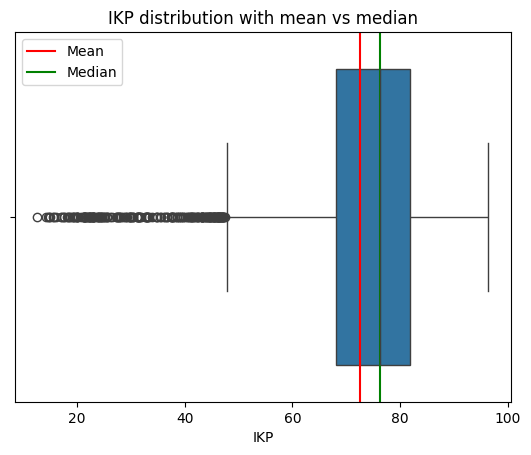

In [24]:
# explore IKP distribution
fsva_raw_df['IKP'].describe()

sns.boxplot(x=fsva_raw_df['IKP'])
plt.axvline(fsva_raw_df["IKP"].mean(), color='red', label='Mean')
plt.axvline(fsva_raw_df["IKP"].median(), color='green', label='Median')

plt.legend()
plt.title("IKP distribution with mean vs median")

plt.show()

In [25]:
# aggregate to province level
fsva_clean = (
    fsva_raw_df
    .groupby(['province', 'year'])[['Komposit', 'IKP']]
    .median()
    .reset_index()
)

In [26]:
# rename columns
fsva_clean.rename(columns={
    'Komposit': 'fsi',
    'IKP': 'fsi_score'
}, inplace=True)

In [27]:
# check fsva_clean
print(fsva_clean.head())
print(fsva_clean.shape)

  province  year  fsi  fsi_score
0     ACEH  2020  5.0      74.57
1     ACEH  2021  6.0      76.08
2     ACEH  2022  5.0      74.63
3     ACEH  2023  6.0      76.66
4     ACEH  2024  6.0      77.19
(204, 4)


In [28]:
# check number of provinces per year
fsva_clean.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


**Poverty and Population Data (BPS)**

In [29]:
# rename poverty data columns
bps_poverty_raw_df  = bps_poverty_raw_df.rename(columns={
    'Provinsi': 'province',
    'Garis Kemiskinan - Maret (Rp)': 'poverty_line',
    'Jumlah Penduduk Miskin - Maret (ribu) (Ribu)': 'poor_population',
    'Persentase Penduduk Miskin - Maret': 'poverty_rate'
})

In [30]:
# rename population data columns
bps_population_raw_df = bps_population_raw_df.rename(columns={
    'Provinsi': 'province',
    'Jumlah Penduduk (Ribu)': 'total_population'
})

In [31]:
# clean string
for df in [bps_poverty_raw_df , bps_population_raw_df]:
    df['province'] = df['province'].astype(str).str.upper().str.strip()

In [32]:
# filter invalid rows
bps_poverty_raw_df  = bps_poverty_raw_df [
    (~bps_poverty_raw_df['province'].str.contains('INDONESIA', na=False)) &
    (~bps_poverty_raw_df ['province'].str.contains('CATATAN', na=False)) &
    (~bps_poverty_raw_df['province'].str.contains('TIDAK DILAKUKAN', na=False)) &
    (bps_poverty_raw_df['province'] != '-') &
    (bps_poverty_raw_df['province'] != 'NAN')
]

In [33]:
# debug province names
[x for x in bps_poverty_raw_df['province'].unique() if 'INDO' in x]

[]

In [34]:
# merge poverty data with population data
bps_poverty_raw_df = bps_poverty_raw_df.merge(
    bps_population_raw_df[['province', 'year', 'total_population']],
    on=['province', 'year'],
    how='left'
)

In [35]:
# map Papua regions to original provinces
def map_province(p):
    if p in ['PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']:
        return 'PAPUA'
    elif p == 'PAPUA BARAT DAYA':
        return 'PAPUA BARAT'
    else:
        return p

bps_poverty_raw_df['province_fix'] = bps_poverty_raw_df['province'].apply(map_province)

In [36]:
# check missing population after merge
bps_poverty_raw_df[bps_poverty_raw_df['total_population'].isna()][['province', 'year']].drop_duplicates()

,province,year
101,PAPUA BARAT DAYA,2022
103,PAPUA SELATAN,2022
104,PAPUA TENGAH,2022
105,PAPUA PEGUNUNGAN,2022


In [37]:
# convert selected columns to numeric
cols = ['total_population', 'poor_population', 'poverty_line']

for col in cols:
    bps_poverty_raw_df[col] = (
        bps_poverty_raw_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
    )
    bps_poverty_raw_df[col] = pd.to_numeric(bps_poverty_raw_df[col], errors='coerce')

In [38]:
# check data types of selected columns
bps_poverty_raw_df[cols].dtypes

,0
total_population,float64
poor_population,float64
poverty_line,float64


In [39]:
# handle missing values
bps_poverty_raw_df = bps_poverty_raw_df.dropna(subset=['total_population', 'poor_population', 'poverty_line'])

In [40]:
# aggregate to province level
agg_list = []

for (prov, year), group in bps_poverty_raw_df.groupby(['province_fix', 'year']):

    total_pop = group['total_population'].sum()
    total_poor = group['poor_population'].sum()

    if total_pop == 0 or pd.isna(total_pop):
        continue

    poverty_rate = (total_poor / total_pop) * 100

    poverty_line = (group['poverty_line'] * group['total_population']).sum() / total_pop

    agg_list.append({
        'province': prov,
        'year': year,
        'poverty_rate': poverty_rate,
        'poverty_line': poverty_line
    })

bps_clean = pd.DataFrame(agg_list)

In [41]:
# check province count, missing values, and shape
print(bps_clean.groupby('year')['province'].nunique())

print(bps_clean.isna().sum())

print(bps_clean.shape)

bps_clean.head()

year
2020    34
2021    34
2022    34
2023    34
2024    34
2025    34
Name: province, dtype: int64
province        0
year            0
poverty_rate    0
poverty_line    0
dtype: int64
(204, 4)


,province,year,poverty_rate,poverty_line
0,ACEH,2020,15.448824,522126.0
1,ACEH,2021,15.640925,541109.0
2,ACEH,2022,14.919285,579227.0
3,ACEH,2023,14.715002,627534.0
4,ACEH,2024,14.483510,661227.0


In [42]:
sorted(bps_clean['province'].unique())

['ACEH',
 'BALI',
 'BANTEN',
 'BENGKULU',
 'DI YOGYAKARTA',
 'DKI JAKARTA',
 'GORONTALO',
 'JAMBI',
 'JAWA BARAT',
 'JAWA TENGAH',
 'JAWA TIMUR',
 'KALIMANTAN BARAT',
 'KALIMANTAN SELATAN',
 'KALIMANTAN TENGAH',
 'KALIMANTAN TIMUR',
 'KALIMANTAN UTARA',
 'KEPULAUAN BANGKA BELITUNG',
 'KEPULAUAN RIAU',
 'LAMPUNG',
 'MALUKU',
 'MALUKU UTARA',
 'NUSA TENGGARA BARAT',
 'NUSA TENGGARA TIMUR',
 'PAPUA',
 'PAPUA BARAT',
 'RIAU',
 'SULAWESI BARAT',
 'SULAWESI SELATAN',
 'SULAWESI TENGAH',
 'SULAWESI TENGGARA',
 'SULAWESI UTARA',
 'SUMATERA BARAT',
 'SUMATERA SELATAN',
 'SUMATERA UTARA']

# **Data Integration**

**Merging Datasets**

In [43]:
print(fsva_clean.columns)
print(food_clean.columns)
print(bps_clean.columns)

Index(['province', 'year', 'fsi', 'fsi_score'], dtype='object')
Index(['province', 'year', 'chili_price', 'eggs_price', 'garlic_price',
       'beef_price', 'chicken_price', 'chicken_broiler_price', 'oil_price',
       'onions_price', 'rice_price', 'sugar_price'],
      dtype='object')
Index(['province', 'year', 'poverty_rate', 'poverty_line'], dtype='object')


In [44]:
print(fsva_clean.shape)
print(food_clean.shape)
print(bps_clean.shape)

(204, 4)
(204, 12)
(204, 4)


In [45]:
len(set(fsva_clean['province']))
len(set(food_clean['province']))
len(set(bps_clean['province']))

34

In [46]:
# check province mismatch across datasets
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

{'KALIMANTAN  TENGAH',
 'KEP. BANGKA BELITUNG',
 'KEP. RIAU',
 'SULAWESI  TENGGARA'}

In [47]:
# standardize province names
mapping_province = {
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'DI YOGYAKARTA': 'DAERAH ISTIMEWA YOGYAKARTA'
}

In [48]:
# apply province name mapping
for df in [fsva_clean, food_clean, bps_clean]:
    df['province'] = df['province'].replace(mapping_province)

In [49]:
# recheck province mismatch after mapping
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

{'KALIMANTAN  TENGAH', 'SULAWESI  TENGGARA'}

In [50]:
# normalize province names format
for df in [fsva_clean, food_clean, bps_clean]:
    df['province'] = (
        df['province']
        .str.upper()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
    )

In [51]:
# final check for province mismatch
set(fsva_clean['province']) - set(food_clean['province'])
set(fsva_clean['province']) - set(bps_clean['province'])

set()

In [52]:
# merge datasets
df = fsva_clean.merge(food_clean, on=['province', 'year'], how='inner')
df = df.merge(bps_clean, on=['province', 'year'], how='inner')

In [53]:
# check number of provinces per year after merge
df.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


In [54]:
# check final dataset shape and preview
df.shape
df.head(204)

,province,year,fsi,fsi_score,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price,poverty_rate,poverty_line
0,ACEH,2020,5.0,74.57,32454.775,24277.195,27873.405,133545.040,28688.150,27966.310,13926.885,37454.915,10071.950,14370.070,15.448824,522126.0
1,ACEH,2021,6.0,76.08,37695.300,24856.380,26878.910,143272.525,29233.695,28676.815,15393.135,33084.295,9900.000,13500.000,15.640925,541109.0
2,ACEH,2022,5.0,74.63,48638.840,27860.225,26586.135,147054.050,29948.165,30000.000,20319.235,35890.205,10323.065,14730.835,14.919285,579227.0
3,ACEH,2023,6.0,76.66,40100.000,29049.070,34445.765,150791.765,30017.045,29906.250,19000.000,34450.700,12111.050,15000.000,14.715002,627534.0
4,ACEH,2024,6.0,77.19,48971.650,28684.690,40000.000,150606.960,31113.200,31360.535,20000.000,37246.500,13755.110,18000.000,14.483510,661227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,SUMATERA UTARA,2021,5.0,74.16,33791.220,24000.000,27832.820,130000.000,33820.940,33794.260,15275.000,30560.160,11250.000,13000.000,8.997335,525756.0
200,SUMATERA UTARA,2022,5.0,71.74,45266.790,26316.015,27139.595,135000.000,33000.000,33486.840,19804.855,35000.000,11554.100,14267.315,8.390164,561004.0
201,SUMATERA UTARA,2023,6.0,76.89,37870.320,28106.495,34825.985,140000.000,32431.530,31399.875,18709.025,31526.720,12984.355,15000.000,8.057076,602999.0
202,SUMATERA UTARA,2024,6.0,77.31,47036.465,28800.000,40000.000,140000.000,33826.040,33831.085,20000.000,38241.850,14114.450,17750.000,7.877666,642423.0


In [55]:
df.columns
df.head()

,province,year,fsi,fsi_score,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price,poverty_rate,poverty_line
0,ACEH,2020,5.0,74.57,32454.775,24277.195,27873.405,133545.040,28688.150,27966.310,13926.885,37454.915,10071.950,14370.070,15.448824,522126.0
1,ACEH,2021,6.0,76.08,37695.300,24856.380,26878.910,143272.525,29233.695,28676.815,15393.135,33084.295,9900.000,13500.000,15.640925,541109.0
2,ACEH,2022,5.0,74.63,48638.840,27860.225,26586.135,147054.050,29948.165,30000.000,20319.235,35890.205,10323.065,14730.835,14.919285,579227.0
3,ACEH,2023,6.0,76.66,40100.000,29049.070,34445.765,150791.765,30017.045,29906.250,19000.000,34450.700,12111.050,15000.000,14.715002,627534.0
4,ACEH,2024,6.0,77.19,48971.650,28684.690,40000.000,150606.960,31113.200,31360.535,20000.000,37246.500,13755.110,18000.000,14.483510,661227.0


In [56]:
df.shape
df.describe()

,year,fsi,fsi_score,chili_price,eggs_price,garlic_price,beef_price,chicken_price,chicken_broiler_price,oil_price,onions_price,rice_price,sugar_price,poverty_rate,poverty_line
count,204.000000,204.000000,204.000000,204.00000,204.000000,204.000000,204.00000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,2022.500000,5.127451,73.143309,49233.27451,28096.788578,35371.795343,133251.23723,35533.214730,35602.822255,18551.679730,37500.443456,13291.866887,15515.478382,9.864450,574849.074396
std,1.712026,1.227128,11.419235,14256.65571,3643.733919,7502.939289,13186.51456,4878.990707,5078.950079,3345.841048,6656.485768,2124.665585,2061.428846,4.555937,128415.969792
min,2020.000000,1.000000,27.740000,24351.47000,21012.745000,20858.225000,94806.54500,25361.415000,24716.080000,12482.135000,24000.000000,8884.285000,11265.370000,3.826145,350264.000000
25%,2021.000000,5.000000,70.183750,38086.39875,25337.731250,28508.361250,124956.59625,32036.995000,32093.207500,15427.226250,33165.782500,11540.575000,14005.246250,6.330987,477869.500000
50%,2022.500000,5.750000,75.880000,48195.21750,28000.000000,35017.942500,133200.72750,35137.697500,35464.752500,19090.692500,36340.560000,13250.000000,15000.000000,8.426309,556021.500000
75%,2024.000000,6.000000,80.488750,57714.01750,30290.667500,40659.492500,141176.34875,38635.041250,38855.447500,21000.000000,40280.666250,14724.795000,17750.000000,12.693085,659265.000000
max,2025.000000,6.000000,90.935000,85728.54500,37472.875000,59896.330000,164386.53000,46647.730000,47154.555000,28750.000000,65000.000000,18418.650000,21000.000000,21.703324,956833.000000


# **Exploratory Data Analysis (EDA)**

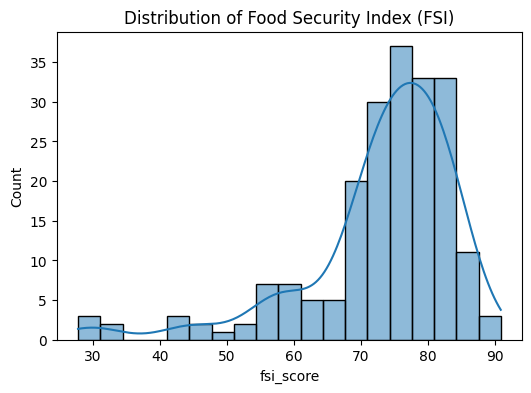

In [57]:
# plot distribution of fsi_score
plt.figure(figsize=(6,4))
sns.histplot(df['fsi_score'], kde=True)
plt.title('Distribution of Food Security Index (FSI)')
plt.show()

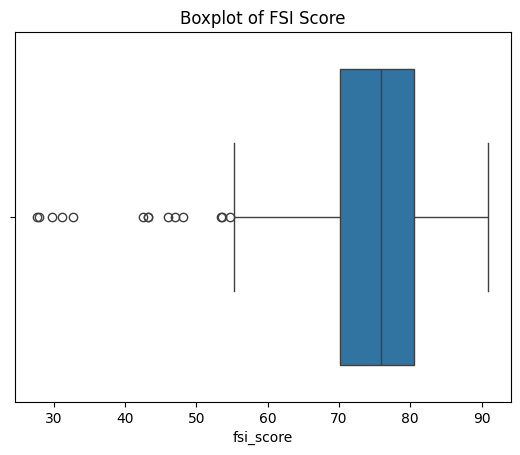

In [58]:
# plot boxplot of fsi_score
sns.boxplot(x=df['fsi_score'])
plt.title('Boxplot of FSI Score')
plt.show()

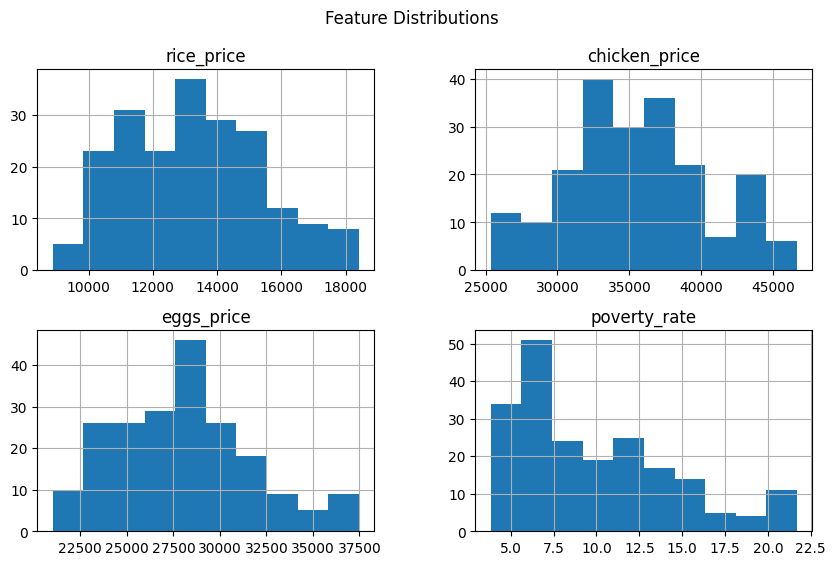

In [59]:
# plot distribution of selected features
features = ['rice_price', 'chicken_price', 'eggs_price', 'poverty_rate']

df[features].hist(figsize=(10,6))
plt.suptitle('Feature Distributions')
plt.show()

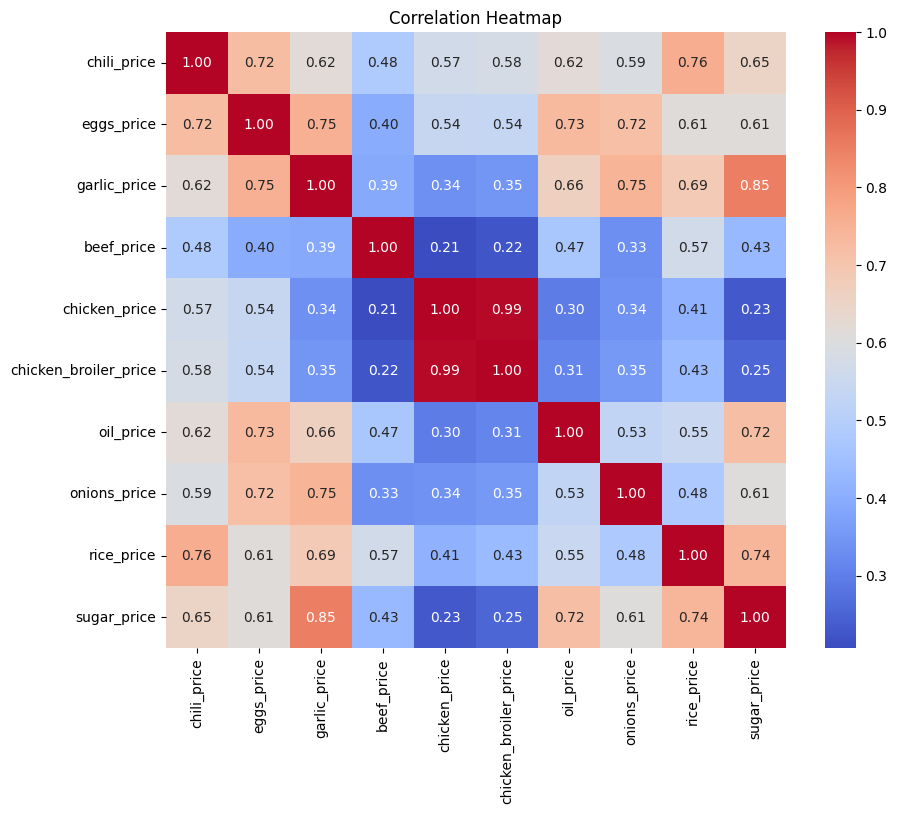

In [60]:
# plot correlation heatmap
corr = food_clean.drop(columns=['province', 'year']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

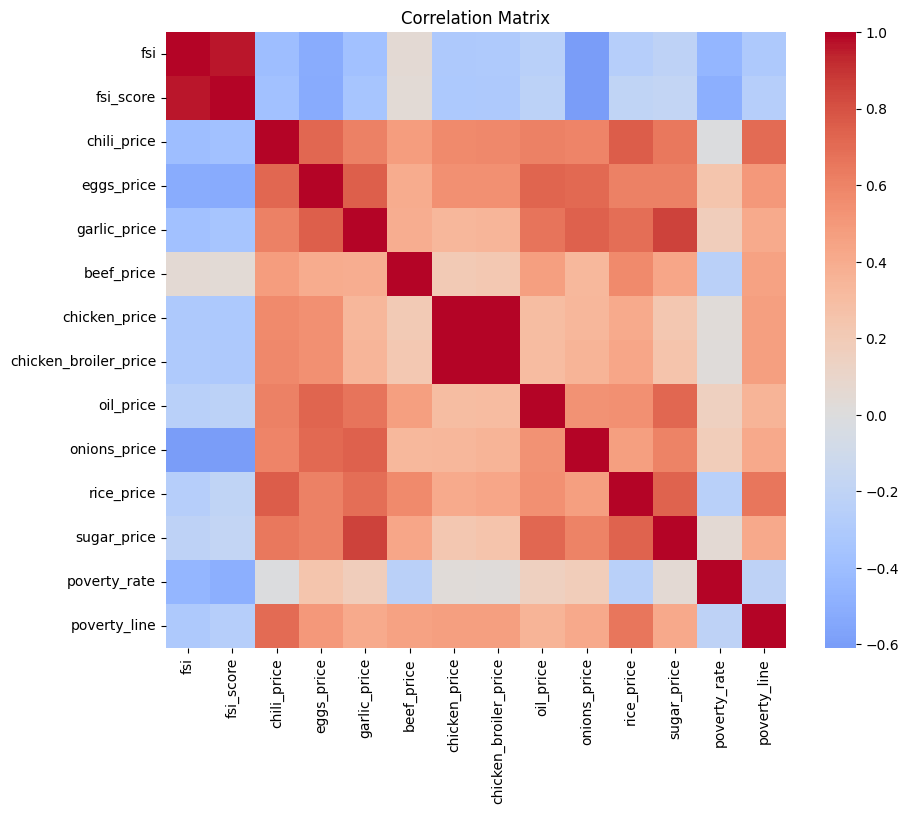

In [61]:
# plot correlation matrix
plt.figure(figsize=(10,8))
corr = df.drop(columns=['province', 'year']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

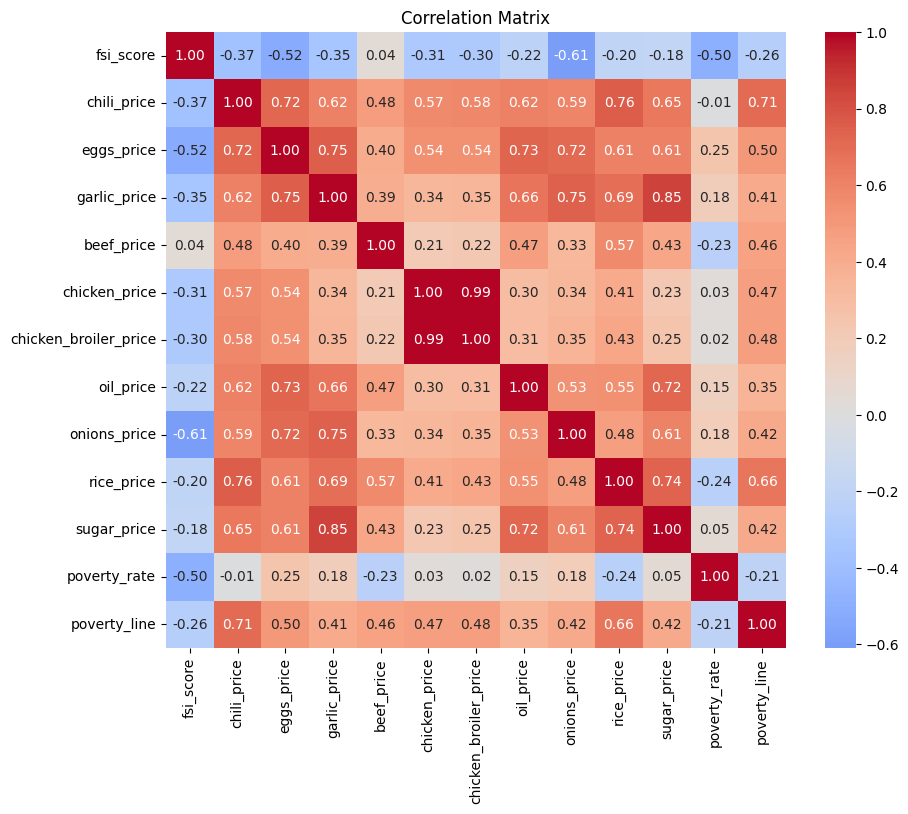

In [62]:
# plot correlation matrix
corr = df.drop(columns=['province', 'year', 'fsi']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title('Correlation Matrix')
plt.show()

In [63]:
corr['fsi_score'].sort_values()

,fsi_score
onions_price,-0.609239
eggs_price,-0.524437
poverty_rate,-0.501856
chili_price,-0.371098
garlic_price,-0.348313
chicken_price,-0.310547
chicken_broiler_price,-0.304448
poverty_line,-0.259258
oil_price,-0.224737
rice_price,-0.195963


In [64]:
# check top correlations with fsi_score
corr = df.drop(columns=['province', 'year', 'fsi']).corr()
corr_target = corr['fsi_score'].drop('fsi_score').sort_values(ascending=False)
print(corr_target.head(10))

beef_price               0.040323
sugar_price             -0.177622
rice_price              -0.195963
oil_price               -0.224737
poverty_line            -0.259258
chicken_broiler_price   -0.304448
chicken_price           -0.310547
garlic_price            -0.348313
chili_price             -0.371098
poverty_rate            -0.501856
Name: fsi_score, dtype: float64


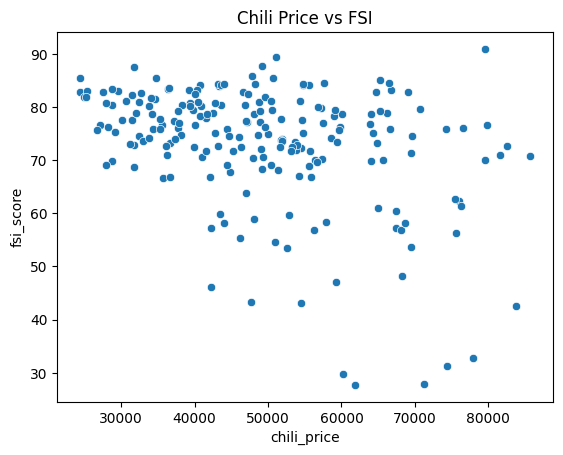

In [65]:
# plot relationship between chili price and fsi_score
sns.scatterplot(x=df['chili_price'], y=df['fsi_score'])
plt.title('Chili Price vs FSI')
plt.show()

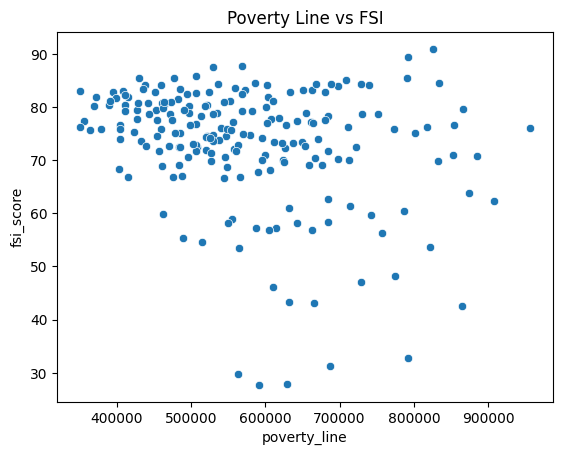

In [66]:
# plot relationship between poverty line and fsi_score
sns.scatterplot(x=df['poverty_line'], y=df['fsi_score'])
plt.title('Poverty Line vs FSI')
plt.show()

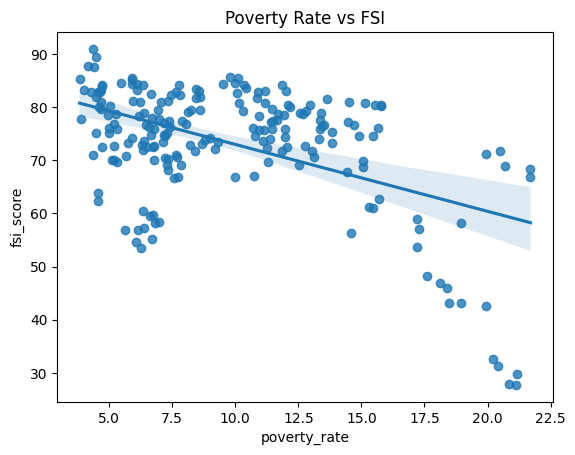

In [67]:
# plot relationship between poverty rate and fsi_score
sns.regplot(x=df['poverty_rate'], y=df['fsi_score'])
plt.title('Poverty Rate vs FSI')
plt.show()

# **Splitting Dataset**

In [68]:
train_df = df[df['year'] <= 2023]
test_df  = df[df['year'] >= 2024]

x_train = train_df.drop(columns=["fsi_score", "fsi", "province", "year"])
y_train = train_df["fsi_score"]

x_test = test_df.drop(columns=["fsi_score", "fsi", "province", "year"])
y_test = test_df["fsi_score"]

print(x_train.shape)
print(x_test.shape)

(136, 12)
(68, 12)


# **Preprocessing**

Handle Inconsistent Data

In [69]:
# check data types (should be numeric)
print(x_train.dtypes)
print(x_test.dtypes)

chili_price              float64
eggs_price               float64
garlic_price             float64
beef_price               float64
chicken_price            float64
chicken_broiler_price    float64
oil_price                float64
onions_price             float64
rice_price               float64
sugar_price              float64
poverty_rate             float64
poverty_line             float64
dtype: object
chili_price              float64
eggs_price               float64
garlic_price             float64
beef_price               float64
chicken_price            float64
chicken_broiler_price    float64
oil_price                float64
onions_price             float64
rice_price               float64
sugar_price              float64
poverty_rate             float64
poverty_line             float64
dtype: object


In [70]:
# check non-numeric values (if any)
print(x_train.select_dtypes(include=['object']).columns)

Index([], dtype='object')


Handle Missing Values

In [71]:
# check missing values before handling
print(x_train.isna().sum())
print(x_test.isna().sum())

chili_price              0
eggs_price               0
garlic_price             0
beef_price               0
chicken_price            0
chicken_broiler_price    0
oil_price                0
onions_price             0
rice_price               0
sugar_price              0
poverty_rate             0
poverty_line             0
dtype: int64
chili_price              0
eggs_price               0
garlic_price             0
beef_price               0
chicken_price            0
chicken_broiler_price    0
oil_price                0
onions_price             0
rice_price               0
sugar_price              0
poverty_rate             0
poverty_line             0
dtype: int64


In [72]:
# fill missing values using median (based on training data only)
median_values = x_train.median()

x_train = x_train.fillna(median_values)
x_test  = x_test.fillna(median_values)

In [73]:
# check missing values after handling
print(x_train.isna().sum())
print(x_test.isna().sum())

chili_price              0
eggs_price               0
garlic_price             0
beef_price               0
chicken_price            0
chicken_broiler_price    0
oil_price                0
onions_price             0
rice_price               0
sugar_price              0
poverty_rate             0
poverty_line             0
dtype: int64
chili_price              0
eggs_price               0
garlic_price             0
beef_price               0
chicken_price            0
chicken_broiler_price    0
oil_price                0
onions_price             0
rice_price               0
sugar_price              0
poverty_rate             0
poverty_line             0
dtype: int64


Handle Outliers (IQR Method)

In [74]:
# check distribution before outlier handling
print(x_train.describe())

        chili_price    eggs_price  garlic_price     beef_price  chicken_price  \
count    136.000000    136.000000    136.000000     136.000000     136.000000   
mean   43376.691691  27130.990588  31857.176507  130240.321287   34986.465110   
std    11621.670756   3510.721528   5866.385551   12559.142242    4725.736481   
min    24351.470000  21012.745000  20858.225000   94806.545000   25361.415000   
25%    34582.200000  24256.023750  27080.597500  122505.022500   31941.563750   
50%    41625.627500  27031.637500  30632.535000  130000.000000   34793.737500   
75%    50782.196250  29126.420000  35200.831250  140000.000000   38074.663750   
max    75516.380000  36951.365000  49592.770000  162431.060000   46647.730000   

       chicken_broiler_price     oil_price  onions_price    rice_price  \
count             136.000000    136.000000    136.000000    136.000000   
mean            34938.538309  17220.914963  35850.996397  12200.296728   
std              4884.382829   3056.735496   596

In [75]:
# handle outliers using IQR (capping)
for col in x_train.columns:
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    x_train.loc[:, col] = x_train[col].clip(lower=lower_bound, upper=upper_bound)
    x_test.loc[:, col]  = x_test[col].clip(lower=lower_bound, upper=upper_bound)

In [76]:
# check distribution after outlier handling
print(x_train.describe())

        chili_price    eggs_price  garlic_price     beef_price  chicken_price  \
count    136.000000    136.000000    136.000000     136.000000     136.000000   
mean   43373.499122  27127.165285  31834.967197  130255.684798   34986.465110   
std    11612.832595   3500.209617   5803.295849   12516.444040    4725.736481   
min    24351.470000  21012.745000  20858.225000   96262.556250   25361.415000   
25%    34582.200000  24256.023750  27080.597500  122505.022500   31941.563750   
50%    41625.627500  27031.637500  30632.535000  130000.000000   34793.737500   
75%    50782.196250  29126.420000  35200.831250  140000.000000   38074.663750   
max    75082.190625  36432.014375  47381.181875  162431.060000   46647.730000   

       chicken_broiler_price     oil_price  onions_price    rice_price  \
count             136.000000    136.000000    136.000000    136.000000   
mean            34938.538309  17219.979049  35630.411140  12200.296728   
std              4884.382829   3053.886293   542

In [77]:
# check for duplicate rows in train and test data
print("Duplicate train:", x_train.duplicated().sum())
print("Duplicate test :", x_test.duplicated().sum())

Duplicate train: 0
Duplicate test : 0


In [78]:
# check feature variance (detect near-constant features)
print(x_train.var())

chili_price              1.348579e+08
eggs_price               1.225147e+07
garlic_price             3.367824e+07
beef_price               1.566614e+08
chicken_price            2.233259e+07
chicken_broiler_price    2.385720e+07
oil_price                9.326221e+06
onions_price             2.943278e+07
rice_price               2.297323e+06
sugar_price              8.621605e+05
poverty_rate             2.165511e+01
poverty_line             1.272704e+10
dtype: float64


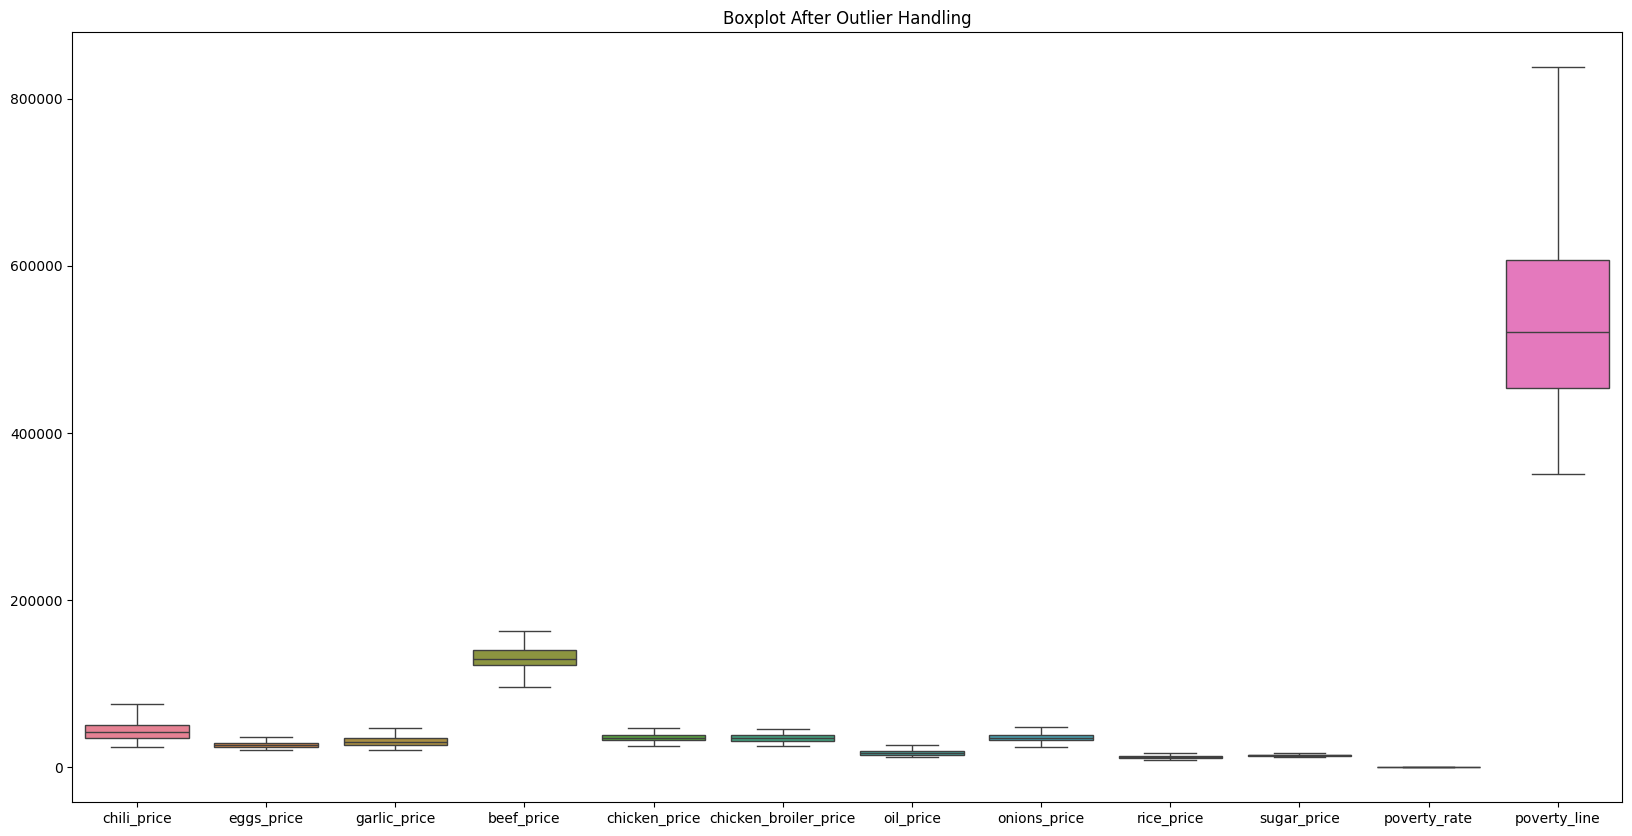

In [79]:
# boxplot to visualize outliers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
sns.boxplot(data=x_train)
plt.title("Boxplot After Outlier Handling")
plt.show()

# Normalization (Standard Scaler)

In [80]:
from sklearn.preprocessing import StandardScaler       # for feature scaling

In [81]:
# normalization using standard scaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

In [82]:
# check scaled data (mean ~0, std ~1)
print(x_train_scaled.mean(axis=0))
print(x_train_scaled.std(axis=0))

[ 3.26536184e-17  6.66133815e-16 -2.35106052e-16 -3.13474736e-16
 -6.56337729e-16 -2.10289302e-15  4.31027763e-16  4.44089210e-16
 -2.35106052e-16 -1.30614473e-16 -1.30614473e-16 -4.63681381e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [83]:
# check mean and standard deviation after scaling (should be ~0 and ~1)
np.mean(x_train_scaled, axis=0)
np.std(x_train_scaled, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [84]:
# check missing values after scaling
print(np.isnan(x_train_scaled).sum())
print(np.isnan(x_test_scaled).sum())

0
0


In [85]:
# final validation check
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(136, 12)
(68, 12)


In [86]:
# FINAL CLEAN CHECK

print("Missing values train:", np.isnan(x_train_scaled).sum())
print("Missing values test :", np.isnan(x_test_scaled).sum())

print("Infinite train:", np.isinf(x_train_scaled).sum())
print("Infinite test :", np.isinf(x_test_scaled).sum())

Missing values train: 0
Missing values test : 0
Infinite train: 0
Infinite test : 0


#VALIDATION (GROUP CROSS VALIDATION)

In [87]:
from sklearn.model_selection import GroupKFold, cross_val_score

groups = train_df["province"]

gkf = GroupKFold(n_splits=5)

# MODELLING & PERFORMANCE EVALUATION

In [88]:
from sklearn.linear_model import LinearRegression      # baseline linear model
from sklearn.linear_model import Lasso                 # regularized linear model (feature selection)
from sklearn.ensemble import RandomForestRegressor     # tree-based ensemble model
from xgboost import XGBRegressor                       # gradient boosting model
from sklearn.svm import SVR                           # support vector regression (non-linear model)

models = {
    'Linear Regression': LinearRegression(),
    'LASSO': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'XGBoost': XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    )
}

In [89]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# store evaluation results
results = []

# train and evaluate each model
for name, model in models.items():

    # train model and prediction (exclude Random forest and XGBoost)
    if name in ["Linear Regression", "LASSO", "SVR"]:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

    # evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # save results
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

# convert to dataframe
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.160188,6.286986,0.639838
1,LASSO,5.220577,6.227510,0.646620
2,Random Forest,7.710986,11.067106,-0.116045
3,SVR,6.786814,9.690767,0.144284
4,XGBoost,6.493859,9.096328,0.246044


In [90]:
for name, model in models.items():

    if name in ["Linear Regression", "LASSO", "SVR"]:
        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)
    else:  # Random Forest, XGBoost
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    gap = train_r2 - test_r2

    print(f"\n{name}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R² : {test_r2:.4f}")
    print(f"Gap      : {gap:.4f}")


Linear Regression
Train R²: 0.6440
Test R² : 0.6398
Gap      : 0.0041

LASSO
Train R²: 0.6420
Test R² : 0.6466
Gap      : -0.0046

Random Forest
Train R²: 0.9756
Test R² : -0.1160
Gap      : 1.0916

SVR
Train R²: 0.2836
Test R² : 0.1443
Gap      : 0.1393

XGBoost
Train R²: 1.0000
Test R² : 0.2460
Gap      : 0.7540


# HYPERPARAMETER TUNING


In [91]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ),
    param_grid=xgb_param_grid,
    cv=gkf,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(x_train, y_train, groups=groups)

best_xgb = xgb_grid.best_estimator_

print("Best XGB Parameters:")
print(xgb_grid.best_params_)
print("Best CV Score:")
print(xgb_grid.best_score_)

Best XGB Parameters:
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score:
0.23649498527073343


In [92]:
best_xgb.fit(x_train, y_train)

xgb_pred = best_xgb.predict(x_test)

print("R²:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

R²: 0.3963082849614529
MAE: 5.941968839308793
RMSE: 8.139558369581115


# VOTING ENSEMBLE MODEL

In [93]:
from sklearn.ensemble import VotingRegressor

ensemble_model = VotingRegressor([
    ('mlr', LinearRegression()),
    ('lasso', Lasso(alpha=0.1)),
    ('rf', RandomForestRegressor(random_state=42)),
    ('svr', SVR()),
    ('xgb', XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        learning_rate=0.01,
        max_depth=5,
        n_estimators=200,
        subsample=1.0
    ))
])

# FINAL MODEL EVALUATION

In [94]:
ensemble_model.fit(x_train_scaled, y_train)

ensemble_pred = ensemble_model.predict(x_test_scaled)

ensemble_mae = mean_absolute_error(
    y_test,
    ensemble_pred
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ensemble_pred
    )
)

ensemble_r2 = r2_score(
    y_test,
    ensemble_pred
)

print("Ensemble Results")
print("-----------------")
print("MAE :", ensemble_mae)
print("RMSE:", ensemble_rmse)
print("R²  :", ensemble_r2)

Ensemble Results
-----------------
MAE : 4.782995913471131
RMSE: 6.019227583210239
R²  : 0.6698623466038904


In [95]:
train_pred = ensemble_model.predict(x_train_scaled)

train_r2 = r2_score(
    y_train,
    train_pred
)

test_r2 = r2_score(
    y_test,
    ensemble_pred
)

print("Ensemble")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R² : {test_r2:.4f}")
print(f"Gap      : {train_r2 - test_r2:.4f}")

Ensemble
Train R²: 0.8079
Test R² : 0.6699
Gap      : 0.1380


In [96]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

final_results = []

# ==========================
# Linear Regression
# ==========================
linear_pred = models['Linear Regression'].predict(x_test_scaled)

final_results.append({
    'Model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test, linear_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, linear_pred)),
    'R2': r2_score(y_test, linear_pred)
})

# ==========================
# LASSO
# ==========================
lasso_pred = models['LASSO'].predict(x_test_scaled)

final_results.append({
    'Model': 'LASSO',
    'MAE': mean_absolute_error(y_test, lasso_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, lasso_pred)),
    'R2': r2_score(y_test, lasso_pred)
})

# ==========================
# Random Forest
# ==========================
rf_pred = models['Random Forest'].predict(x_test)

final_results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'R2': r2_score(y_test, rf_pred)
})

# ==========================
# SVR
# ==========================
svr_pred = models['SVR'].predict(x_test_scaled)

final_results.append({
    'Model': 'SVR',
    'MAE': mean_absolute_error(y_test, svr_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, svr_pred)),
    'R2': r2_score(y_test, svr_pred)
})

# ==========================
# Tuned XGBoost
# ==========================
xgb_pred = best_xgb.predict(x_test)

final_results.append({
    'Model': 'XGBoost (Tuned)',
    'MAE': mean_absolute_error(y_test, xgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'R2': r2_score(y_test, xgb_pred)
})

# ==========================
# Voting Ensemble
# ==========================
final_results.append({
    'Model': 'Voting Ensemble',
    'MAE': ensemble_mae,
    'RMSE': ensemble_rmse,
    'R2': ensemble_r2
})

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)

final_results_df.round(3)

,Model,MAE,RMSE,R2
0,Voting Ensemble,4.783,6.019,0.670
1,LASSO,5.221,6.228,0.647
2,Linear Regression,5.160,6.287,0.640
3,XGBoost (Tuned),5.942,8.140,0.396
4,SVR,6.787,9.691,0.144
5,Random Forest,7.711,11.067,-0.116


In [97]:
# use best model
best_model = ensemble_model

# prediction
y_pred = best_model.predict(x_test_scaled)

# comparison dataframe
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison_df.head()

,Actual,Predicted
0,77.19,75.489488
1,69.16,74.091989
2,87.64,85.943994
3,77.79,81.786681
4,78.86,79.957412


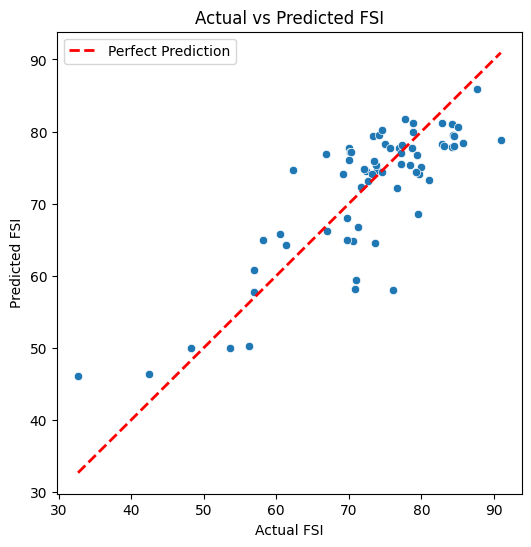

In [98]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

# ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel('Actual FSI')
plt.ylabel('Predicted FSI')
plt.title('Actual vs Predicted FSI')
plt.legend()

plt.show()

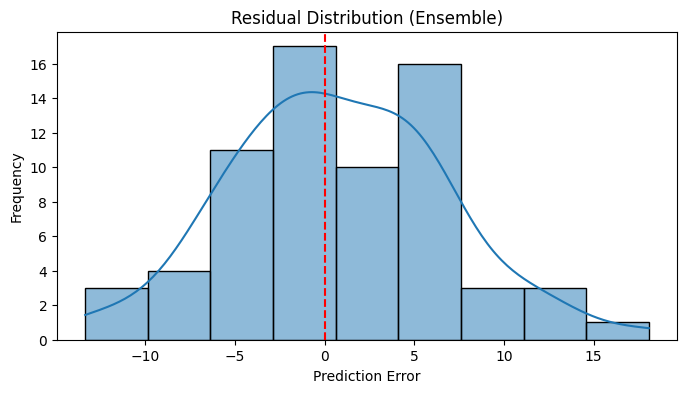

In [99]:
# calculate residuals
residuals = y_test - y_pred

# residual distribution
plt.figure(figsize=(8,4))

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(
    x=0,
    color='red',
    linestyle='--'
)

plt.title('Residual Distribution (Ensemble)')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

plt.show()

#MODEL INTERPRETATION

In [100]:
# feature importance from lasso
lasso_model = models['LASSO']

importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': lasso_model.coef_
})

# absolute coefficient
importance_df['Absolute'] = abs(importance_df['Coefficient'])

# sort by importance
importance_df = importance_df.sort_values(
    by='Absolute',
    ascending=False
)

importance_df

,Feature,Coefficient,Absolute
7,onions_price,-6.748726,6.748726
10,poverty_rate,-5.841789,5.841789
9,sugar_price,2.948902,2.948902
8,rice_price,-2.877431,2.877431
3,beef_price,2.004812,2.004812
2,garlic_price,1.162304,1.162304
0,chili_price,-1.022282,1.022282
11,poverty_line,-1.012234,1.012234
1,eggs_price,-1.003755,1.003755
6,oil_price,0.528285,0.528285


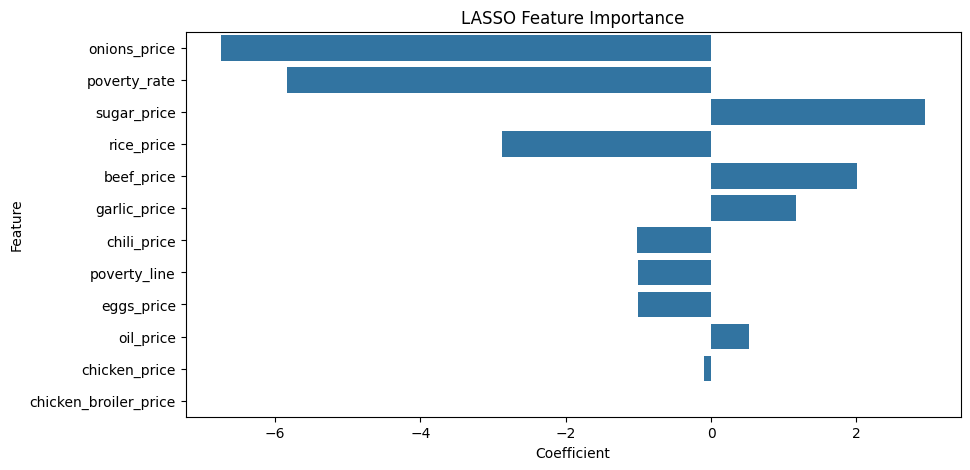

In [101]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance_df,
    x='Coefficient',
    y='Feature'
)

plt.title('LASSO Feature Importance')
plt.show()

# FUTURE FSI PREDICTION

In [102]:
future_df = df[df['year'] == 2025].copy()

In [103]:
future_x = future_df.drop(
    columns=['fsi_score', 'fsi', 'province', 'year']
)

In [104]:
future_x_scaled = scaler.transform(future_x)

In [105]:
future_2026_pred = best_model.predict(future_x_scaled)

In [106]:
future_df['predicted_fsi_2026'] = future_2026_pred

In [107]:
# average prediction
avg_2026 = future_df['predicted_fsi_2026'].mean()

prediction_summary = pd.DataFrame({
    'Year': ['2026'],
    'Average FSI': [round(avg_2026, 2)]
})

prediction_summary

,Year,Average FSI
0,2026,70.55


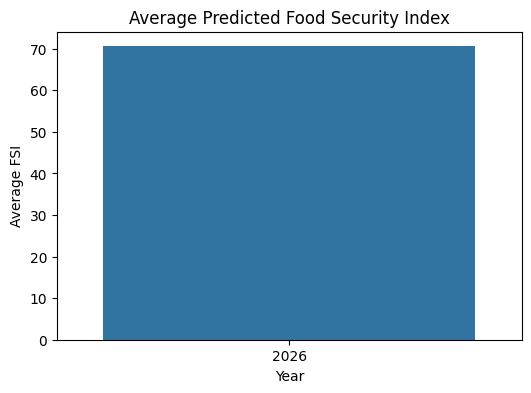

In [108]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=prediction_summary,
    x='Year',
    y='Average FSI'
)

plt.title('Average Predicted Food Security Index')
plt.show()

In [109]:
best_row = final_results_df.iloc[0]

print("Best Model :", best_row['Model'])
print("Best R2 Score :", best_row['R2'])

print("Predicted Average FSI 2026 :", avg_2026)

Best Model : Voting Ensemble
Best R2 Score : 0.6698623466038904
Predicted Average FSI 2026 : 70.54540499858571


In [110]:
comparison_df.corr()

,Actual,Predicted
Actual,1.00000,0.82326
Predicted,0.82326,1.00000


In [111]:
from scipy.stats import pearsonr
pearsonr(y_test, y_pred)

PearsonRResult(statistic=np.float64(0.8232600157532424), pvalue=np.float64(6.95107583941915e-18))

In [112]:
comparison_df.to_csv(
    'prediction_result.csv',
    index=False
)

In [113]:
prediction_result = pd.DataFrame({
    'Province': test_df['province'],
    'Actual': y_test,
    'Predicted': ensemble_pred
})

prediction_result

,Province,Actual,Predicted
4,ACEH,77.19,75.489488
5,ACEH,69.16,74.091989
10,BALI,87.64,85.943994
11,BALI,77.79,81.786681
16,BANTEN,78.86,79.957412
...,...,...,...
191,SUMATERA BARAT,78.67,77.768965
196,SUMATERA SELATAN,75.62,77.684380
197,SUMATERA SELATAN,79.26,74.452254
202,SUMATERA UTARA,77.31,78.127206


In [114]:
top5_lowest = (
    future_df[['province', 'predicted_fsi_2026']]
    .sort_values(by='predicted_fsi_2026', ascending=True)
    .head(5)
)

print(top5_lowest)

                      province  predicted_fsi_2026
143                      PAPUA           43.666262
149                PAPUA BARAT           50.261821
119                     MALUKU           51.309021
125               MALUKU UTARA           54.949496
96   KEPULAUAN BANGKA BELITUNG           58.796330


In [115]:
lr_pred_2026 = models['Linear Regression'].predict(future_x_scaled)
lasso_pred_2026 = models['LASSO'].predict(future_x_scaled)
svr_pred_2026 = models['SVR'].predict(future_x_scaled)

rf_pred_2026 = models['Random Forest'].predict(future_x)
xgb_pred_2026 = best_xgb.predict(future_x)

ensemble_pred_2026 = ensemble_model.predict(future_x_scaled)

In [116]:
avg_predictions = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'LASSO',
        'Random Forest',
        'SVR',
        'XGBoost',
        'Ensemble'
    ],
    '2026': [
        lr_pred_2026.mean(),
        lasso_pred_2026.mean(),
        rf_pred_2026.mean(),
        svr_pred_2026.mean(),
        xgb_pred_2026.mean(),
        ensemble_pred_2026.mean()
    ]
})

print(avg_predictions)

               Model       2026
0  Linear Regression  73.124144
1              LASSO  71.955484
2      Random Forest  64.496041
3                SVR  73.899799
4            XGBoost  69.250702
5           Ensemble  70.545405


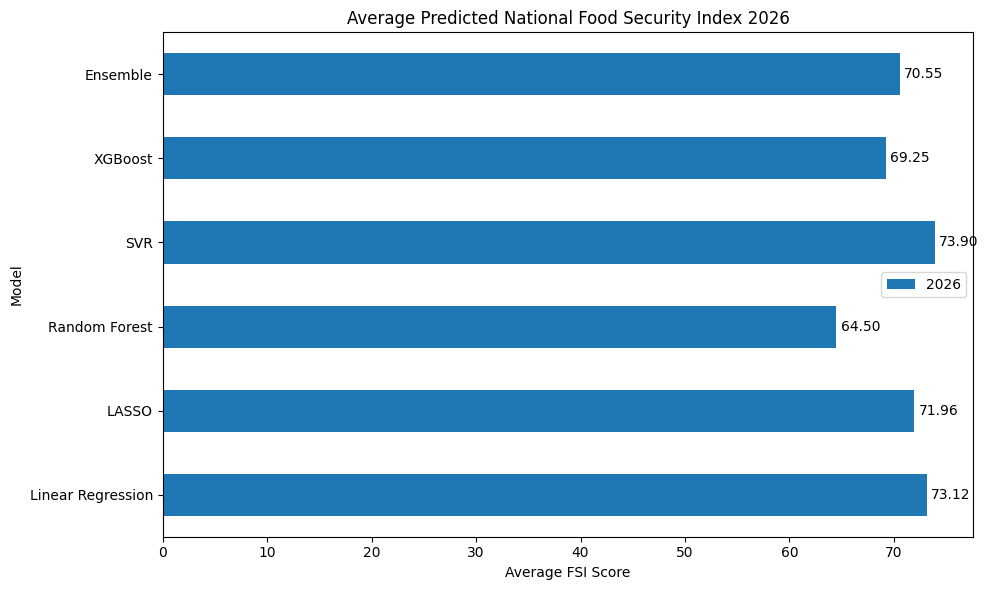

In [117]:
import matplotlib.pyplot as plt

plot_df = avg_predictions.set_index('Model')

ax = plot_df.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Average Predicted National Food Security Index 2026')
plt.xlabel('Average FSI Score')
plt.ylabel('Model')

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',     # 2 decimal places
        padding=3
    )

plt.tight_layout()
plt.show()

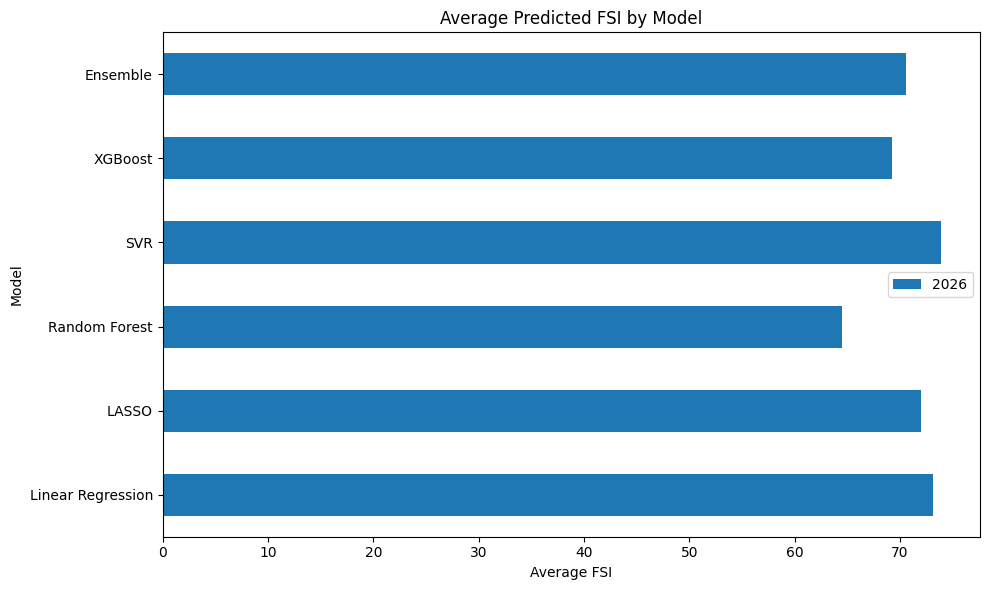

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = avg_predictions.set_index('Model')

ax = plot_df[['2026']].plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Average Predicted FSI by Model')
plt.xlabel('Average FSI')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

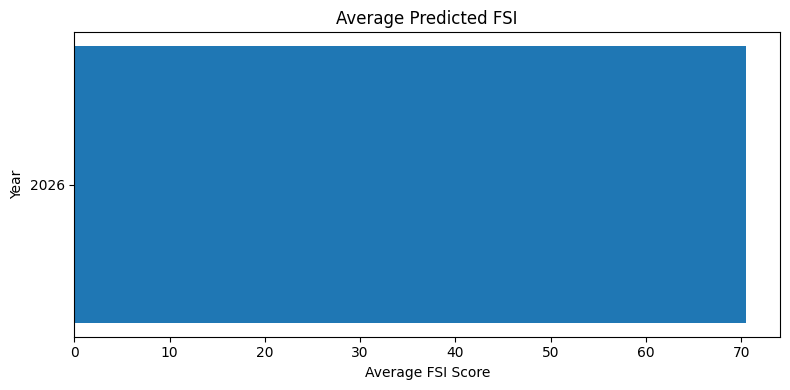

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.barh(
    prediction_summary['Year'],
    prediction_summary['Average FSI']
)

plt.title('Average Predicted FSI')
plt.xlabel('Average FSI Score')
plt.ylabel('Year')

plt.tight_layout()
plt.show()